In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [18]:
#CRR pricing 
def crr_put_price(S0,K,T,r,sigma,steps,american=True):
    if steps <= 0:
        raise ValueError("steps must be positive")
    if T <= 0:
        # At maturity, option is just intrinsic value
        return max(K - S0, 0.0)
    if sigma <= 0:
        # Degenerate case not central here, but let's handle gracefully
        # Under deterministic growth S_T = S0*exp(rT)
        ST = S0 * np.exp(r * T)
        euro = np.exp(-r*T) * max(K - ST, 0.0)
        if american:
            return max(euro, max(K - S0, 0.0))
        return euro

    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    disc = np.exp(-r * dt)
    p = (np.exp(r * dt) - d) / (u - d)

    if not (0 < p < 1):
        raise ValueError("Risk-neutral probability out of bounds. Try more steps or check parameters.")

    # Terminal stock prices at time T
    j = np.arange(steps + 1)  # number of up moves
    ST = S0 * (u ** j) * (d ** (steps - j))

    # Terminal put payoffs
    option_values = np.maximum(K - ST, 0.0)

    # Backward induction
    for i in range(steps - 1, -1, -1):
        # continuation values at time i
        option_values = disc * (p * option_values[1:i+2] + (1 - p) * option_values[0:i+1])

        if american:
            # stock prices at time i
            j = np.arange(i + 1)
            S_i = S0 * (u ** j) * (d ** (i - j))
            exercise = np.maximum(K - S_i, 0.0)
            option_values = np.maximum(option_values, exercise)

    return float(option_values[0])

In [19]:
# Baseline parameters
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.25
steps = 500

euro_price = crr_put_price(S0, K, T, r, sigma, steps, american=False)
amer_price = crr_put_price(S0, K, T, r, sigma, steps, american=True)
premium = amer_price - euro_price

print(f"European put price : {euro_price:.6f}")
print(f"American put price : {amer_price:.6f}")
print(f"Early-exercise premium : {premium:.6f}")

European put price : 7.453999
American put price : 7.972371
Early-exercise premium : 0.518373


In [20]:
def run_sanity_tests():
    print("Running sanity tests...")

    # Test 1: American >= European
    P_eur = crr_put_price(100, 100, 1.0, 0.05, 0.25, 500, american=False)
    P_ame = crr_put_price(100, 100, 1.0, 0.05, 0.25, 500, american=True)
    assert P_ame >= P_eur - 1e-10, "American put should be at least European put"
    print(" American >= European")

    # Test 2: Put value falls as S0 rises
    P_lowS = crr_put_price(90, 100, 1.0, 0.05, 0.25, 500, american=True)
    P_highS = crr_put_price(110, 100, 1.0, 0.05, 0.25, 500, american=True)
    assert P_lowS >= P_highS - 1e-10, "Put should be worth more when stock price is lower"
    print(" Put value falls as S0 rises")

    # Test 3: Put value rises as sigma rises
    P_lowvol = crr_put_price(100, 100, 1.0, 0.05, 0.15, 500, american=True)
    P_highvol = crr_put_price(100, 100, 1.0, 0.05, 0.35, 500, american=True)
    assert P_highvol >= P_lowvol - 1e-10, "Put should be worth more when volatility rises"
    print(" Put value rises as sigma rises")

    # Extra self-check from assignment: American put >= intrinsic
    intrinsic = max(K - S0, 0)
    assert P_ame >= intrinsic - 1e-10, "American put should never be below intrinsic value"
    print(" American put >= intrinsic value")

    print("All sanity tests passed.")

run_sanity_tests()

Running sanity tests...
 American >= European
 Put value falls as S0 rises
 Put value rises as sigma rises
 American put >= intrinsic value
All sanity tests passed.


In [21]:
step_list = [25, 50, 100, 200, 500, 1000]

rows = []
for n in step_list:
    eur = crr_put_price(S0, K, T, r, sigma, n, american=False)
    ame = crr_put_price(S0, K, T, r, sigma, n, american=True)
    rows.append({
        "steps": n,
        "European Put": eur,
        "American Put": ame,
        "Early-Exercise Premium": ame - eur
    })

conv_df = pd.DataFrame(rows)
print(conv_df.to_string(index=False))

 steps  European Put  American Put  Early-Exercise Premium
    25      7.549650      8.052667                0.503017
    50      7.409627      7.952030                0.542403
   100      7.434252      7.963611                0.529359
   200      7.446589      7.969091                0.522502
   500      7.453999      7.972371                0.518373
  1000      7.456470      7.973439                0.516969


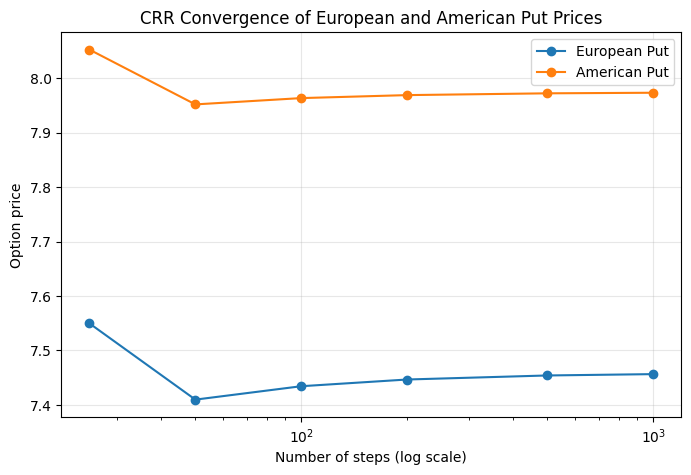

In [22]:
plt.figure(figsize=(8,5))
plt.plot(conv_df["steps"], conv_df["European Put"], marker='o', label="European Put")
plt.plot(conv_df["steps"], conv_df["American Put"], marker='o', label="American Put")
plt.xscale("log")
plt.xlabel("Number of steps (log scale)")
plt.ylabel("Option price")
plt.title("CRR Convergence of European and American Put Prices")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
S_grid = np.linspace(60, 140, 25)
T_grid = np.linspace(0.05, 2.0, 25)

S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)
price_surface = np.zeros_like(S_mesh)

surface_steps = 200  # 500 for every grid point is slower; 200 is a good compromise for plotting

for i in range(T_mesh.shape[0]):
    for j in range(T_mesh.shape[1]):
        price_surface[i, j] = crr_put_price(
            S0=S_mesh[i, j],
            K=100,
            T=T_mesh[i, j],
            r=0.05,
            sigma=0.25,
            steps=surface_steps,
            american=True
        )

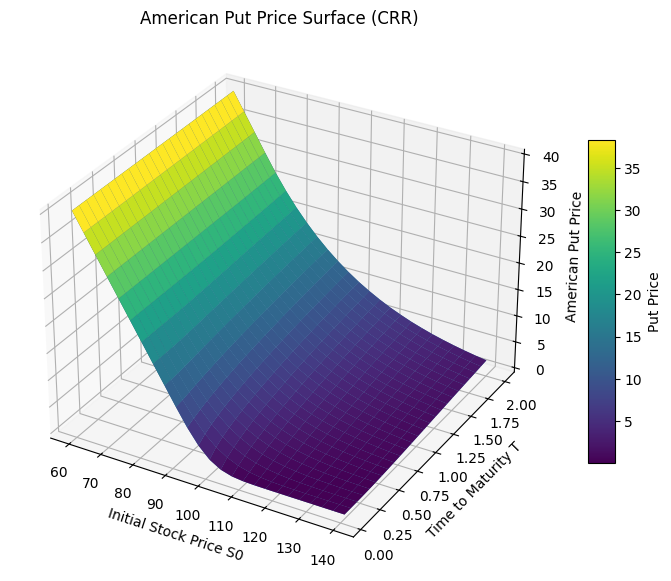

In [28]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(S_mesh, T_mesh, price_surface, edgecolor='none', alpha=0.9)

ax.set_xlabel("Initial Stock Price S0")
ax.set_ylabel("Time to Maturity T")
ax.set_zlabel("American Put Price")
ax.set_title("American Put Price Surface (CRR)")

surf = ax.plot_surface(S_mesh, T_mesh, price_surface, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12, label="Put Price")
plt.show()

In [ ]:
def american_put_boundary(S0, K, T, r, sigma, steps, tol=1e-10):
    """
    Compute the early-exercise boundary for an American put in a CRR tree.

    Returns
    -------
    times : np.ndarray
        Time points t_i from 0 to T
    boundary : np.ndarray
        At each time t_i, the highest stock price node at which immediate
        exercise is optimal. np.nan if no exercise region exists at that time.
    """
    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    disc = np.exp(-r * dt)
    p = (np.exp(r * dt) - d) / (u - d)

    if not (0 < p < 1):
        raise ValueError("Risk-neutral probability out of bounds.")

    # Build stock tree
    stock_tree = []
    for i in range(steps + 1):
        j = np.arange(i + 1)
        S_i = S0 * (u ** j) * (d ** (i - j))
        stock_tree.append(S_i)

    # Terminal option values
    option_values = np.maximum(K - stock_tree[steps], 0.0)

    boundary = np.full(steps + 1, np.nan)

    # Terminal boundary computed from actual ITM nodes
    terminal_ex_nodes = np.where(stock_tree[steps] < K)[0]
    if len(terminal_ex_nodes) > 0:
        boundary[steps] = stock_tree[steps][terminal_ex_nodes[-1]]

    # Backward induction
    for i in range(steps - 1, -1, -1):
        cont = disc * (
            p * option_values[1:i+2] + (1 - p) * option_values[0:i+1]
        )

        exercise = np.maximum(K - stock_tree[i], 0.0)

        # Mark exercise region
        exercise_nodes = np.where(exercise >= cont - tol)[0]

        if len(exercise_nodes) > 0:
            boundary[i] = stock_tree[i][exercise_nodes[-1]]

        option_values = np.maximum(cont, exercise)

    times = np.linspace(0, T, steps + 1)
    return times, boundary

     time  boundary_stock
26  0.052       74.774831
27  0.054       75.615530
28  0.056       74.774831
29  0.058       75.615530
30  0.060       74.774831
31  0.062       75.615530
32  0.064       74.774831
33  0.066       75.615530
34  0.068       74.774831
35  0.070       75.615530
36  0.072       74.774831
37  0.074       75.615530
38  0.076       74.774831
39  0.078       75.615530
40  0.080       74.774831
41  0.082       75.615530
42  0.084       74.774831
43  0.086       75.615530
44  0.088       74.774831
45  0.090       75.615530


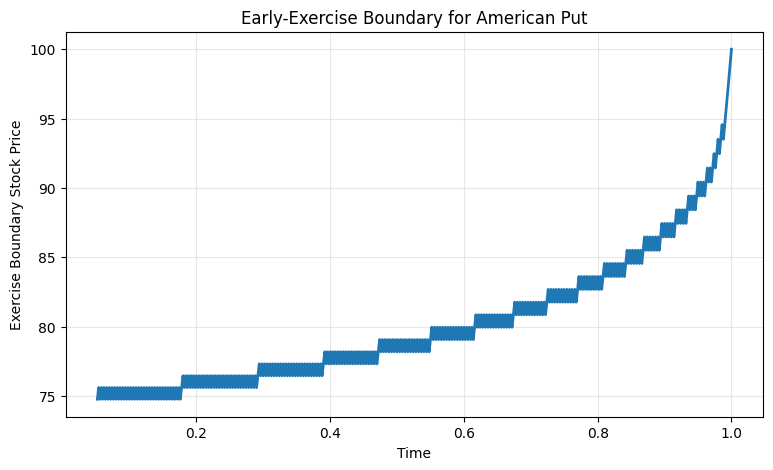

In [27]:
times, boundary = american_put_boundary(
    S0=100, K=100, T=1.0, r=0.05, sigma=0.25, steps=500
)

boundary_df = pd.DataFrame({
    "time": times,
    "boundary_stock": boundary
})

# Optional: show only rows where a boundary exists
print(boundary_df.dropna().head(20))

plt.figure(figsize=(9,5))
plt.plot(times, boundary, lw=2)
plt.xlabel("Time")
plt.ylabel("Exercise Boundary Stock Price")
plt.title("Early-Exercise Boundary for American Put")
plt.grid(True, alpha=0.3)
plt.show()

Reflection:Week4 

For an American put, early exercise appears primarily when the option is sufficiently in the money, meaning the stock price is well below the strike. In that region, the intrinsic value K−S is already large, and the benefit of waiting for further downside may be outweighed by the value of exercising immediately.

This is financially sensible because exercising early allows the holder to receive the strike-related cash payoff sooner and invest that cash at the risk-free rate. For a deep in-the-money put, the remaining upside from keeping the option alive can be limited, while the time value of receiving cash earlier becomes important. Early exercise is therefore more attractive when:

The put is deep in the money,
interest rates are positive, so cash received earlier has value,
and there is less remaining time value in waiting.